# Import Libraries and Data

In [170]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# This dataset has 8 columns and 10,000 rows.
raw_df = pd.read_csv(r'Insert Downloaded Dataset Path Here', compression = 'zip')

In [172]:
df = raw_df.copy()

# Inital Data Inspection

In [173]:
df.shape

(10000, 8)

In [174]:
df.columns

Index(['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent',
       'Payment Method', 'Location', 'Transaction Date'],
      dtype='object')

In [175]:
df.head(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28
8,TXN_4717867,NaN,5,3.0,15.0,NaN,Takeaway,2023-07-28
9,TXN_2064365,Sandwich,5,4.0,20.0,NaN,In-store,2023-12-31


In [176]:
df.tail(20)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9980,TXN_6796890,Tea,4,1.5,6.0,UNKNOWN,NaN,2023-08-24
9981,TXN_4583012,ERROR,5,4.0,20.0,Digital Wallet,NaN,2023-02-27
9982,TXN_8567525,Cookie,2,1.0,2.0,NaN,Takeaway,2023-12-30
9983,TXN_9226047,Smoothie,3,4.0,12.0,Cash,NaN,UNKNOWN
9984,TXN_3142496,Smoothie,UNKNOWN,4.0,4.0,Cash,Takeaway,2023-07-27
9985,TXN_3297457,Cake,2,3.0,6.0,NaN,UNKNOWN,2023-01-03
9986,TXN_2858441,Sandwich,2,4.0,8.0,Credit Card,In-store,2023-12-14
9987,TXN_1784478,Juice,5,3.0,15.0,Cash,NaN,2023-07-31
9988,TXN_9594133,Cake,5,3.0,NaN,ERROR,NaN,NaN
9989,TXN_1741685,Juice,5,3.0,15.0,Cash,NaN,2023-08-18


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [178]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

### Initial Observations:
- UNKNOWN, NaN and ERROR results are present in all columns except 'Transaction ID'.
- Price Per Unit and Total Spent are not consistently displayed to two decimal places.
- All column datatypes are 'object' which should not be the case.
- There are no duplicates in our data.

# Addressing Missing and Invalid Values

## Replacing Invalid Values with Null Values

In [179]:
# The following code replaces UNKNOWN and ERROR values with null values:
df['Payment Method'] = df['Payment Method'].replace(['UNKNOWN','ERROR'], pd.NA)
df['Location'] = df['Location'].replace(['UNKNOWN','ERROR'], pd.NA)
df['Transaction Date'] = df['Transaction Date'].replace(['UNKNOWN','ERROR'], pd.NA)

## Reconstructing Recoverable Data

Quantity, Price Per Unit and Total Spent columns are mathematically related by:

Quantity * Price Per Unit = Total Spent

We can use this to reconstruct missing values in the data.

In [180]:
# Converting column datatypes:
# errors = 'coerce' will convert any non-numeric values to NaN.
df[['Quantity', 'Price Per Unit', 'Total Spent']] = df[['Quantity', 'Price Per Unit', 'Total Spent']].apply(pd.to_numeric, errors = 'coerce')

In [181]:
# Reconstructing missing values in the dataset:
df['Quantity'] = df['Quantity'].fillna(df['Total Spent'] / df['Price Per Unit'])
df['Price Per Unit'] = df['Price Per Unit'].fillna(df['Total Spent'] / df['Quantity'])
df['Total Spent'] = df['Total Spent'].fillna(df['Quantity'] * df['Price Per Unit'])

In [182]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity              38
Price Per Unit        38
Total Spent           40
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

There are at most 40 rows that have missing values. These values could not be reconstructed due to multiple missing values in the row.

Rows with missing data make up <= 0.4% of all data. We could use methods such as substituting in values like the median, mean or mode, however, these are not actual observations, reducing the accuracy of the results.

### Validating Cleaned Data
Checking for impossible data:

In [183]:
print((df['Quantity'] < 0).sum())

0


In [184]:
print((df['Price Per Unit'] < 0).sum())

0


In [185]:
print((df['Total Spent'] < 0).sum())

0


Checking the Quantity column for decimals:

In [186]:
print(((df['Quantity'].notna()) & (df['Quantity'] % 1 != 0)).sum())

0


As this returns 0, it means that the calculations above have worked properly.

## Item Column

In [187]:
# To see the all values that appear in the Item column
print(df['Item'].unique())

['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']


Items: Coffee, Cake, Cookie, Salad, Smoothie, Sandwich, Juice, Tea.

### Finding Items' Price Per Unit

In [188]:
df.groupby(['Item', 'Price Per Unit']).count()

Transaction ID  Quantity  Total Spent  \
Item     Price Per Unit                                          
Cake     3.00                      1135      1134         1134   
Coffee   2.00                      1163      1158         1158   
Cookie   1.00                      1086      1084         1084   
ERROR    1.00                        36        36           36   
         1.50                        40        40           40   
         2.00                        32        32           32   
         3.00                        81        81           81   
         4.00                        62        62           62   
         5.00                        39        39           39   
Juice    3.00                      1170      1167         1167   
Salad    5.00                      1146      1144         1144   
Sandwich 4.00                      1126      1122         1122   
Smoothie 4.00                      1091      1089         1089   
Tea      1.50                      1082      1081         1081   
UNKNOWN  1.00                        45        45           45   
         1.50                        42        42           42   
         2.00                        51        51           51   
         3.00                        81        81           81   
         4.00                        76        76           76   
         5.00                        47        47           47   

                         Payment Method  Location  Transaction Date  
Item     Price Per Unit                                              
Cake     3.00                       772       660              1078  
Coffee   2.00                       750       669              1121  
Cookie   1.00                       758       691              1030  
ERROR    1.00                        21        27                35  
         1.50                        29        25                39  
         2.00                        20        19                32  
         3.00                        56        50                78  
         4.00                        46        31                59  
         5.00                        28        20                38  
Juice    3.00                       826       701              1123  
Salad    5.00                       803       712              1097  
Sandwich 4.00                       762       711              1070  
Smoothie 4.00                       740       623              1044  
Tea      1.50                       721       661              1021  
UNKNOWN  1.00                        32        26                43  
         1.50                        28        24                41  
         2.00                        33        34                49  
         3.00                        50        48                78  
         4.00                        51        43                73  
         5.00                        36        27                43

Price Per Unit:

Salad: £5.00, Sandwich: £4.00, Smoothie: £4.00, Juice: £3.00, Cake: £3.00, Coffee: £2.00, Tea: £1.50, Cookie: £1.00

The items with unique prices allow us to fill in missing values in our data.

There is insufficient data to identify the item bought in these rows. In these cases, replace with null values

In [189]:
# The following code uses the Price Per Unit to fill in missing values in the column.
# df['Item'].isin(['UNKNOWN', 'ERROR']) | df['Item'].isna()) locates UNKNOWN and ERROR values, and also searches for any missing values in the Item column.
df.loc[(df['Item'].isin(['UNKNOWN', 'ERROR']) | df['Item'].isna()) & (df['Price Per Unit'] == 5.0), 'Item'] = 'Salad'
df.loc[(df['Item'].isin(['UNKNOWN', 'ERROR']) | df['Item'].isna()) & (df['Price Per Unit'] == 2.0), 'Item'] = 'Coffee'
df.loc[(df['Item'].isin(['UNKNOWN', 'ERROR']) | df['Item'].isna()) & (df['Price Per Unit'] == 1.5), 'Item'] = 'Tea'
df.loc[(df['Item'].isin(['UNKNOWN', 'ERROR']) | df['Item'].isna()) & (df['Price Per Unit'] == 1.0), 'Item'] = 'Cookie'

In [190]:
# For the values that are still UNKNOWN or ERROR, replace with null values:
df.loc[df['Item'].isin(['UNKNOWN', 'ERROR']), 'Item'] = pd.NA

# Formatting Data

### Correcting Decimal Places in 'Price Per Unit' and 'Total Spent' Columns:

In [191]:
pd.set_option('display.float_format', lambda x : '%.2f' % x)

### Converting Transaction Date Datatype:

In [192]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors = 'coerce')

### Ordering Data by Transaction Date and the Items:

In [193]:
df = df.sort_values(by = ['Transaction Date', 'Item'])

### Converting 'object' columns to 'strings'
Columns of the 'object' datatype display both < NA > and NaN for null values. The following code corrects this:

In [194]:
df[['Item', 'Payment Method', 'Location']] = df[['Item', 'Payment Method', 'Location']].astype('string')

# Exploratory Analysis

### Which Items Account for the Highest Recorded Transactional Value?

In [195]:
item_rtv = df.groupby('Item')['Total Spent'].sum().sort_values(ascending = False)

<Axes: title={'center': 'Total Recorded Transactional Value (£)'}, xlabel='Items', ylabel='Sales Value (£)'>

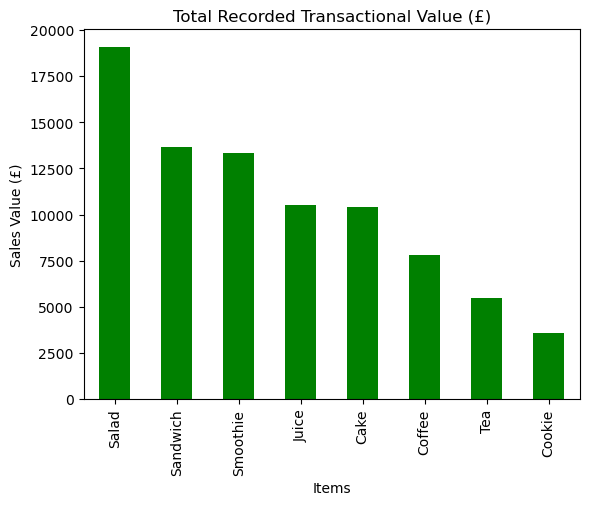

In [196]:
item_rtv.plot(kind = 'bar', title = 'Total Recorded Transactional Value (£)', xlabel = 'Items', ylabel = 'Sales Value (£)', color = 'green')

- We see that Salad generated the highest total recorded transactional value for the cafe at £19,070, while the item that generated the least was Cookies at £3,589.

- The meals, salad and sandwiches, generated the total transactional value while the drinks and snacks generated the lowest.

- Items that were unaccounted for generated £5,141 in total transaction value. Additionally, there are values missing in the 'Total Spent' column, meaning that there could be even more transactions not accounted for. Therefore, we cannot provide the total transactional value generated by each item with certainty.

- Unidentified data represents 0.4% of all data entries, but represents 5.5% of all total transactional value. This could change the distribution of the data providing different results. This should be addressed in order to better understand our data.

### Which Items Had the Highest Quantity Sold?

In [197]:
item_sales = df.groupby('Item')['Quantity'].sum().sort_values(ascending = False)

<Axes: title={'center': 'Quantity Sold'}, xlabel='Items', ylabel='Quantity'>

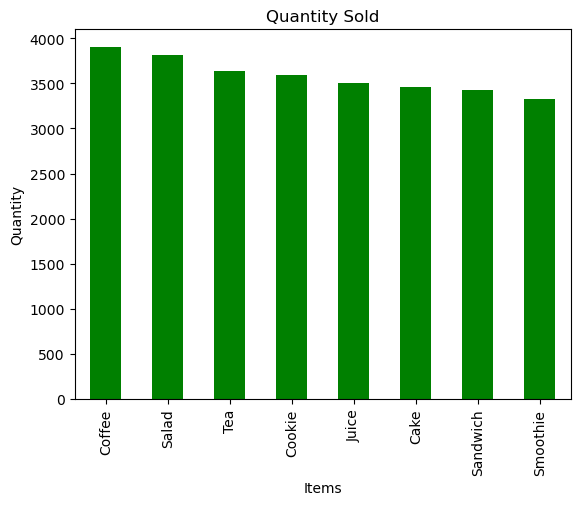

In [198]:
item_sales.plot(kind = 'bar', title = 'Quantity Sold', xlabel = 'Items', ylabel = 'Quantity', color = 'green')

- Recorded quantities sold are relatively similar across products, with a range of 572 units between the highest and lowest values. Coffee had the highest recorded quantity sold, while Smoothie had the lowest.

- Items that are not accounted for had a total quantity sold of 1,471. This makes up a proportion of 5.13% of sales, and once again could change the distribution of this data.

- One observation would be that Tea and Cookies had very similar sales, but Tea generated £1,877 more in recorded transaction value than Cookies. Further analysis should be conducted to determine whether a price change would improve revenue or profit.

### Which Months Had the Highest Transactional Value?

Copy the dataframe:

In [199]:
df2 = df.copy()

Creating a 'Month' column in dataframe by extracting month from date:

In [200]:
df2['Month'] = df2['Transaction Date'].dt.month

In [201]:
count_month = df2['Total Spent'].groupby(df2['Month']).sum()

<Axes: title={'center': 'Transactions Value of Each Month (£) (2023)'}, xlabel='Months', ylabel='Transactional Values (£)'>

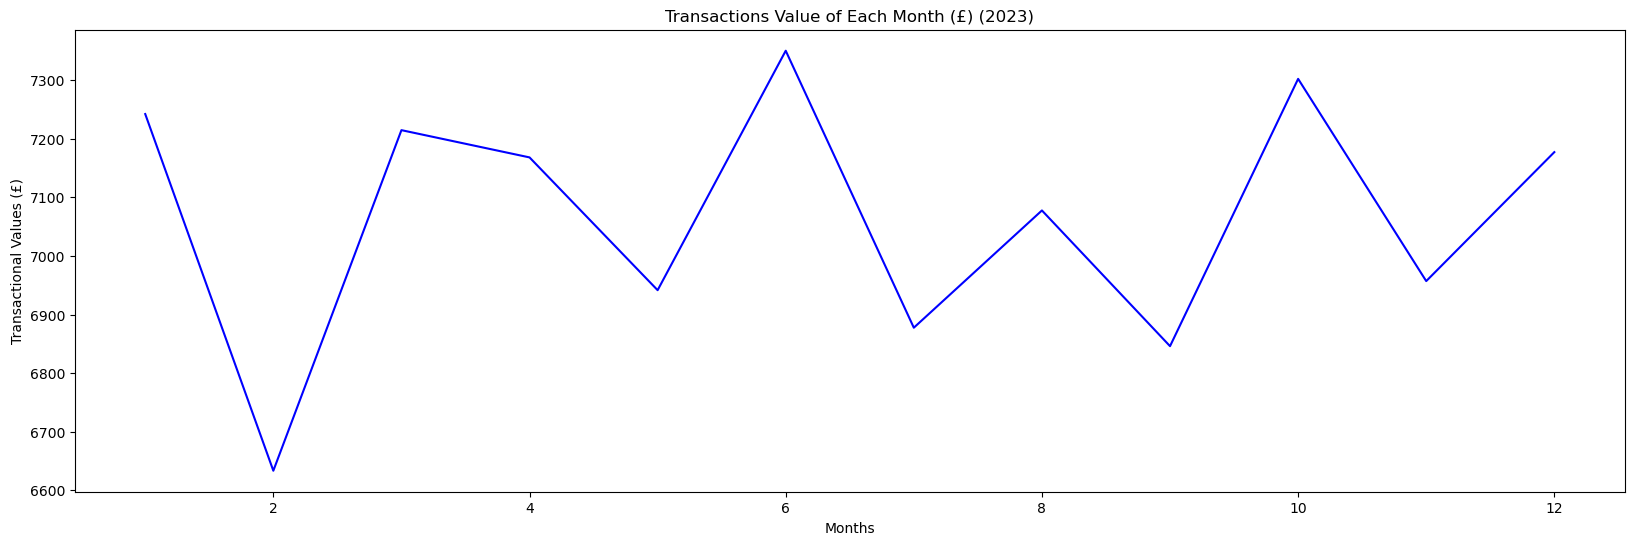

In [202]:
count_month.plot(kind = 'line', figsize = (20,6), title = 'Transactions Value of Each Month (£) (2023)', xlabel = 'Months', ylabel = 'Transactional Values (£)', color = 'blue')

- In 2023, the month with the highest transactional value, £7,350, was June, whereas, the month with the lowest transactional value was February, at £6,633.50. This is a difference of £716.50.

- Apart from February, the transactional values across the months of 2023 are stable, with no clear upward or downward trend.

- Through further exploration, £4165.50 was not assigned a date in 2023. Additionally, values were missing from the 'Total Spent' Column, so we cannot say with certainty that any of these transactional values for months are accurate. We can say that each month made at least the transactional values presented in our data. This missing data will alter interpretations of the data.